In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 57.5 MB/s eta 0:00:00:00:0100:01


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import glob
import os
from tqdm import tqdm
import torch
import torch.nn.functional as F
import rasterio
from sklearn.metrics import jaccard_score

In [7]:
IMAGES = "/kaggle/input/satproject/train/content/train/data"
MASKS = "/kaggle/input/satproject/train/content/train/masks"

In [8]:
image_paths = sorted(glob.glob(os.path.join(IMAGES, "*.tif")))
mask_paths = sorted(glob.glob(os.path.join(MASKS, "*.tif")))

In [9]:
FULL_CLOUD_THRESHOLD = 0.99
NO_CLOUD_THRESHOLD   = 0.01

In [10]:
stats = {
    'filename': [],
    'total_pixels': [],
    'cloud_pixels': [],
    'cloud_fraction': [],
    'label': []
}

In [11]:
mask_fraction_loop = tqdm(mask_paths, desc="Analyzing Masks")
for mpath in mask_fraction_loop:
    with rasterio.open(mpath) as src:
            mask = src.read(1)

    mask = (mask > 0).astype(np.float32)
        
    file_name = os.path.basename(mpath)
    total = mask.size
    cloud = mask.sum()
    frac  = cloud / total

    # Assign label
    if frac >= FULL_CLOUD_THRESHOLD:
        label = 'full_cloud'
    elif frac <= NO_CLOUD_THRESHOLD:
        label = 'no_cloud'
    else:
        label = 'partial_cloud'

    stats['filename'].append(file_name)
    stats['total_pixels'].append(total)
    stats['cloud_pixels'].append(cloud)
    stats['cloud_fraction'].append(frac)
    stats['label'].append(label)

Analyzing Masks: 100%|██████████| 10573/10573 [03:12<00:00, 54.97it/s]


In [12]:
df = pd.DataFrame(stats)

In [13]:
print("Summary statistics for cloud coverage:")
print(df['cloud_fraction'].describe())

Summary statistics for cloud coverage:
count    10573.000000
mean         0.622728
std          0.376250
min          0.000000
25%          0.269360
50%          0.729572
75%          1.000000
max          1.000000
Name: cloud_fraction, dtype: float64


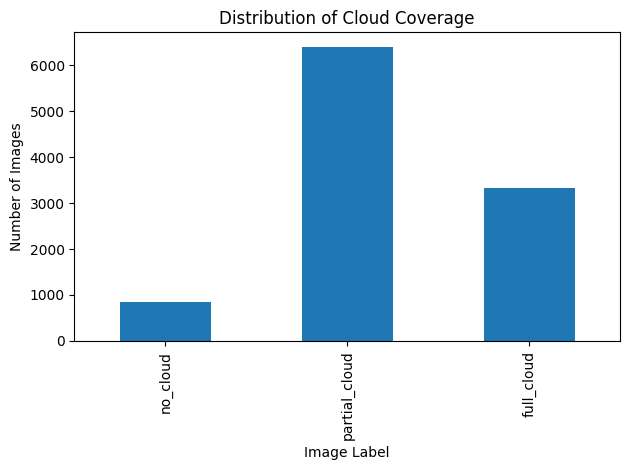

In [53]:
counts = df['label'].value_counts().reindex(['no_cloud', 'partial_cloud', 'full_cloud'])
counts.plot(kind='bar')
plt.title('Distribution of Cloud Coverage')
plt.xlabel('Image Label')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

In [15]:
counts = df['label'].value_counts().reindex(['no_cloud', 'partial_cloud', 'full_cloud'])

In [16]:
total       = counts.sum()
num_classes = counts.size

In [17]:
class_weights = {
    cls: total/(num_classes * cnt)
    for cls, cnt in counts.items()
}

In [18]:
weight_tensor = torch.tensor([
    class_weights['no_cloud'],
    class_weights['partial_cloud'],
    class_weights['full_cloud']
], dtype=torch.float)

In [19]:
class CloudDataset(Dataset):
    def __init__(self, images_paths, mask_paths, device='cuda'):
        self.images_paths = images_paths
        self.mask_paths = mask_paths
        self.device = device

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        current_image = self.images_paths[idx]
        with rasterio.open(current_image) as src:
            bands = torch.tensor(src.read(), dtype=torch.float32)

        # normalize each band
        bands = bands / bands.max()

        r, g, b, infra = bands
        image = torch.stack([r, g, b, infra])

        current_mask = self.mask_paths[idx]
        with rasterio.open(current_mask) as src:
            mask = src.read(1)

        # binary
        mask = torch.from_numpy((mask > 0).astype(np.float32)).unsqueeze(0)

        return image, mask

In [18]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, n_class=1):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        # conv blocks
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.bottleneck = conv_block(512, 1024)
        # upsampling
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = conv_block(128, 64)
        self.final = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

In [48]:
def jaccard_index(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float().view(-1)
    tgt_flat = target.view(-1)
    return 1 - jaccard_score(tgt_flat.cpu().numpy(),
                              pred_bin.cpu().numpy(),
                              zero_division=0)

def dice_loss(pred, target, smooth=1.):
    inter = (pred * target).sum(dim=(1,2))
    denom = pred.sum((1,2)) + target.sum((1,2))
    dice = (2*inter + smooth) / (denom + smooth)
    return 1 - dice.mean()

def calc_loss(logits, target, metrics, bce_weight=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, target.float())
    pred = torch.sigmoid(logits)
    dice = dice_loss(pred, target.float())
    loss = bce * bce_weight + dice * (1 - bce_weight)

    jacc = jaccard_index(pred, target.float())
    bs = target.size(0)
    metrics['jaccard'] += jacc * bs
    metrics['bce']     += bce.item() * bs
    metrics['dice']    += dice.item() * bs
    metrics['loss']    += loss.item() * bs

    return loss

In [ ]:
def train_unet_with_val(
    images_paths,
    mask_paths,
    df,
    val_split: float = 0.2,
    epochs: int = 10,
    batch_size: int = 8,
    lr: float = 1e-3,
    device: str = 'cuda',
    num_workers: int = 4,
    checkpoint_dir: str = 'checkpoints',
    resume_from: str = None
):
    mask_dict = {os.path.basename(p): p for p in mask_paths}
    pairs = [(img, mask_dict[os.path.basename(img)])
             for img in images_paths if os.path.basename(img) in mask_dict]
    fnames = [os.path.basename(img) for img, _ in pairs]
    label_map = df.set_index('filename')['label'].to_dict()
    labels = [label_map[fn] for fn in fnames]

    train_pairs, val_pairs, train_labels, val_labels = train_test_split(
        pairs, labels,
        test_size=val_split,
        stratify=labels,
        random_state=42
    )
    train_images, train_masks = zip(*train_pairs)
    val_images,   val_masks = zip(*val_pairs)

    counts = df['label'].value_counts().reindex(
        ['no_cloud', 'partial_cloud', 'full_cloud']
    )
    total = counts.sum()
    n_class = len(counts)
    class_weights = {
        cls: total/(n_class * cnt)
        for cls, cnt in counts.items()
    }
    sample_weights = torch.tensor(
        [class_weights[lbl] for lbl in train_labels],
        dtype=torch.double
    )
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_ds = CloudDataset(train_images, train_masks, device=device)
    val_ds = CloudDataset(val_images,   val_masks,   device=device)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    model = UNet(in_channels=4, n_class=1).to(device)
    if resume_from:
        model.load_state_dict(torch.load(resume_from))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-8
    )
    os.makedirs(checkpoint_dir, exist_ok=True)
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        train_metrics = {'loss': 0, 'bce': 0, 'dice': 0, 'jaccard': 0}
        pbar_train = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} Train",
            leave=False
        )
        for batch_idx, (image, mask) in enumerate(pbar_train, start=1):
            image, mask = image.to(device), mask.to(device)
            logits = model(image)
            loss = calc_loss(logits, mask, train_metrics)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            avg_loss = train_metrics['loss'] / (batch_idx * batch_size)
            pbar_train.set_postfix(train_loss=f"{avg_loss:.4f}")

        pbar_train.close()
        # aggregate over dataset
        N_train = len(train_ds)
        train_loss = train_metrics['loss'] / N_train

        model.eval()
        val_metrics = {'loss': 0, 'bce': 0, 'dice': 0, 'jaccard': 0}
        pbar_val = tqdm(
            val_loader,
            desc=f"Epoch {epoch}/{epochs} Val  ",
            leave=False
        )
        with torch.no_grad():
            for batch_idx, (image, mask) in enumerate(pbar_val, start=1):
                image, mask = image.to(device), mask.to(device)
                logits = model(image)                        # <--- moved here
                _ = calc_loss(logits, mask, val_metrics)

                avg_val = val_metrics['loss'] / (batch_idx * batch_size)
                pbar_val.set_postfix(val_loss=f"{avg_val:.4f}")

        pbar_val.close()
        N_val = len(val_ds)
        val_loss = val_metrics['loss'] / N_val

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            path = os.path.join(checkpoint_dir, f"best_model_epoch{epoch}.pth")
            torch.save(model.state_dict(), path)
            print(
                f"[Epoch {epoch}] New best val loss: {best_val_loss:.4f}. Saved → {path}")

        scheduler.step()
        print(
            f"Epoch {epoch:2d}  Train loss={train_loss:.4f}  Val loss={val_loss:.4f}")

    return model

In [ ]:
train_unet_with_val(
    image_paths,
    mask_paths,
    df,
    val_split=0.2,
    epochs=20,
    batch_size=8,
    lr=1e-3,
    device='cuda',
    num_workers=4,
    resume_from="checkpoints/best_model_epoch7.pth"
)

In [ ]:
def dice_coefficient(mask1: np.ndarray, mask2: np.ndarray) -> float:
    """Computes the Dice coefficient between two binary masks."""
    intersection = np.sum(mask1 * mask2)
    return (2.0 * intersection + 1e-7) / (np.sum(mask1) + np.sum(mask2) + 1e-7)  # Avoid division by zero

In [ ]:
def predict_mask(model: torch.nn.Module, tiff_path: str, device: str = 'cuda', threshold: float = 0.5) -> np.ndarray:

    model.eval()
    with torch.no_grad():
        with rasterio.open(tiff_path) as src:
            bands = torch.from_numpy(src.read()).float()

        bands = bands / bands.max()

        image = bands.unsqueeze(0)
        image = image.to(device)

        logits = model(image)
        probs = torch.sigmoid(logits)

        pred_mask = (probs.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    return pred_mask

In [ ]:
def evaluate_and_plot(pred_mask: np.ndarray, true_mask: np.ndarray, figsize: tuple = (10,5)) -> float:
    
    dice = dice_coefficient(pred_mask, true_mask)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(true_mask, cmap='gray')
    axes[0].set_title('True Mask')
    axes[0].axis('off')

    axes[1].imshow(pred_mask, cmap='gray')
    axes[1].set_title(f'Predicted Mask\nDice: {dice:.4f}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return dice

In [ ]:
model = UNet(in_channels=4, n_class=1)
model.load_state_dict(torch.load('checkpoints/best_model_epoch3.pth'))
model.to('cuda')

In [ ]:
import random

image_idx = random.randint(0, len(image_paths))
print("Image with index: {}".format(image_idx))

pred = predict_mask(model, image_paths[image_idx], device='cuda')

with rasterio.open(mask_paths[image_idx]) as src:
    true = src.read(1).astype(np.uint8)

dice = evaluate_and_plot(pred, true)
print(f"Dice = {dice:.4f}")